In [1]:
import pandas as pd

# Load the dataset
url = "https://raw.githubusercontent.com/JoannaBroniarek/House-Prices-Advanced-Regression-Techniques/master/dane/train.csv"
df = pd.read_csv(url)

# Display the first few rows
print(df.head())

# List numeric columns
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns
print("Numeric columns:", numeric_columns)


   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD   

In [2]:
# Function to detect outliers using IQR
def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] < lower_bound) | (df[column] > upper_bound)]

# Example: Detect outliers in 'SalePrice'
outliers_saleprice = detect_outliers(df, 'SalePrice')
print(f"Number of outliers in 'SalePrice': {outliers_saleprice.shape[0]}")


Number of outliers in 'SalePrice': 61


In [3]:
# Remove outliers from 'SalePrice'
df_cleaned = df[~df['SalePrice'].isin(outliers_saleprice['SalePrice'])]

# Verify the removal
print(f"Original dataset shape: {df.shape}")
print(f"Cleaned dataset shape: {df_cleaned.shape}")


Original dataset shape: (1460, 81)
Cleaned dataset shape: (1399, 81)


Matplotlib is building the font cache; this may take a moment.


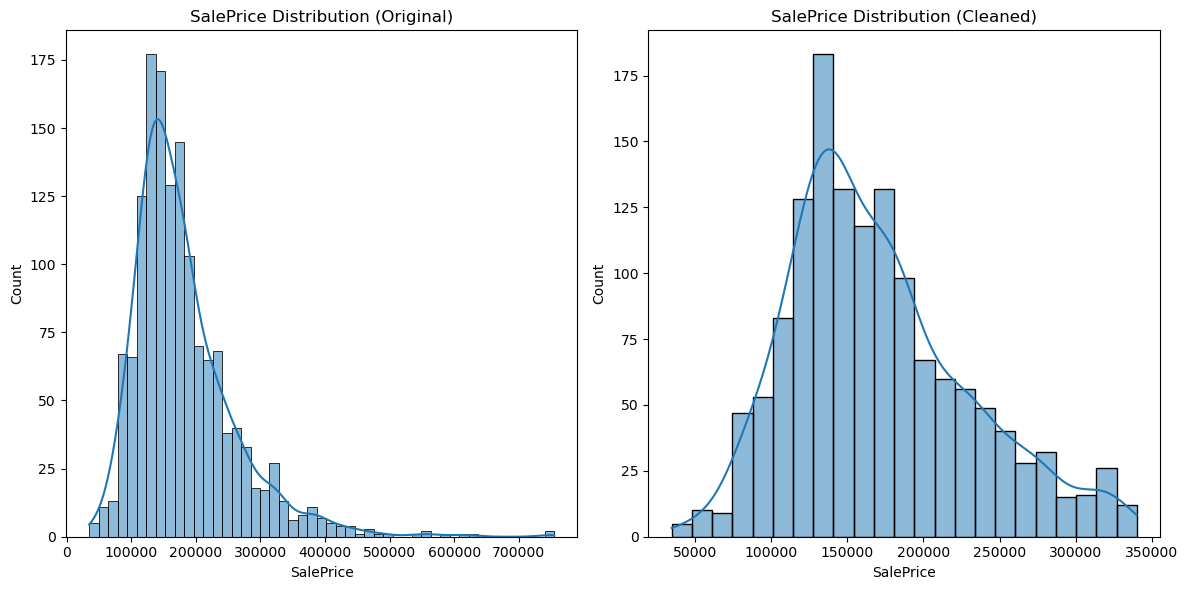

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot distribution of 'SalePrice' before and after cleaning
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.histplot(df['SalePrice'], kde=True)
plt.title('SalePrice Distribution (Original)')

plt.subplot(1, 2, 2)
sns.histplot(df_cleaned['SalePrice'], kde=True)
plt.title('SalePrice Distribution (Cleaned)')

plt.tight_layout()
plt.show()
